# Direct Residual Baseline Checks

This notebook implements the first residual-channel concept-discovery baseline for Residual SCBM.

The baseline question is simple:

> Do the learned residual dimensions already behave like discovered hidden concepts?

Protocol:

1. Load residual outputs from the split folders: `train/`, `val/`, `test/`.
2. Load true synthetic hidden residual labels from the matching dataset split.
3. Assert row alignment for every split.
4. Choose residual-to-hidden matches on validation only.
5. Report final recovery on test.

This is analogous to the concept-bank matching step in `cem-concept-discovery`, but here the residual channel is treated as one global missing-concept space instead of splitting each parent concept.


In [19]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## Select Experiment

Set `EXPERIMENT_PATH` to a Residual SCBM run that contains split-wise residual files:

```text
EXPERIMENT_PATH/train/res_mu.pt
EXPERIMENT_PATH/val/res_mu.pt
EXPERIMENT_PATH/test/res_mu.pt
```

The default below points at the hard synthetic run from the current analysis.


In [20]:
EXPERIMENT_PATH = Path(
    "experiments/scbm_residual/synthetic_res_scbm/hard/"
    "alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-45_5c587"
)

assert EXPERIMENT_PATH.exists(), EXPERIMENT_PATH
EXPERIMENT_PATH


PosixPath('experiments/scbm_residual/synthetic_res_scbm/hard/alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-45_5c587')

## Helpers


In [21]:
def read_config_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path
    with log_path.open("r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)


def get_data_dir_name_from_log(experiment_path: Path):
    log_path = experiment_path / "log.txt"
    assert log_path.exists(), log_path

    data_dir_line = None
    with log_path.open("r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                data_dir_line = line.split("data_dir:", 1)[1].strip()
                break
            if line.startswith("Loading existing synthetic dataset from"):
                data_dir_line = line.split("Loading existing synthetic dataset from", 1)[1].strip()
                break

    if data_dir_line is None:
        raise ValueError(f"Could not find data directory in {log_path}")

    return Path(data_dir_line).name


def infer_data_path(experiment_path: Path):
    cfg = read_config_from_log(experiment_path)
    data_cfg = cfg["data"]
    dataset = data_cfg["dataset"]
    difficulty = data_cfg.get("experiment_type")
    data_dir_name = get_data_dir_name_from_log(experiment_path)

    candidates = []
    if difficulty is not None:
        candidates.append(Path("datasets") / dataset / difficulty / data_dir_name)
    candidates.append(Path("datasets") / dataset / data_dir_name)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError("Could not find data path. Tried: " + ", ".join(map(str, candidates)))


def load_tensor(path: Path):
    assert path.exists(), path
    return torch.load(path, map_location="cpu")


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def load_split(experiment_path: Path, data_path: Path, split: str):
    model_split = experiment_path / split
    data_split = data_path / split

    if not model_split.exists():
        raise FileNotFoundError(
            f"Missing {model_split}. Re-run inference/training after adding deterministic analysis loaders."
        )
    assert data_split.exists(), data_split

    out = {
        "res_mu": load_tensor(model_split / "res_mu.pt"),
        "residual_probs": load_tensor(model_split / "residuals_pred_probs_mean.pt"),
        "residual_probs_std": load_tensor(model_split / "residuals_pred_probs_std.pt"),
        "residual_sample_mean": load_tensor(model_split / "residuals_sample_mean.pt"),
        "hidden_residuals": load_tensor(data_split / "residuals.pt"),
        "hidden_residual_signal": load_tensor(data_split / "residual_signal.pt"),
        "concepts": load_tensor(data_split / "concepts.pt"),
        "y": load_tensor(data_split / "y.pt"),
        "w_hid": load_tensor(data_split / "w_hid.pt"),
    }

    n_model = out["res_mu"].shape[0]
    n_data = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split} row mismatch: model residuals have {n_model} rows, "
        f"but hidden residual labels have {n_data}. The residual dump likely used a shuffled/drop_last loader."
    )
    assert out["residual_probs"].shape[0] == n_data
    assert out["residual_sample_mean"].shape[0] == n_data

    return out


def orientation_free_auc(y_true, score):
    y_true = to_numpy(y_true).astype(int)
    score = to_numpy(score).astype(float)
    if len(np.unique(y_true)) < 2:
        return np.nan, "degenerate"
    raw_auc = roc_auc_score(y_true, score)
    if raw_auc >= 0.5:
        return raw_auc, "positive"
    return 1.0 - raw_auc, "negative"


def residual_hidden_auc_matrix(residual_scores, hidden_residuals):
    R = to_numpy(residual_scores).astype(float)
    H = to_numpy(hidden_residuals).astype(int)

    auc = np.zeros((R.shape[1], H.shape[1]), dtype=float)
    directions = np.empty((R.shape[1], H.shape[1]), dtype=object)

    for r in range(R.shape[1]):
        for h in range(H.shape[1]):
            auc[r, h], directions[r, h] = orientation_free_auc(H[:, h], R[:, r])

    return auc, directions


def plot_auc_matrix(auc, title):
    plt.figure(figsize=(1.15 * auc.shape[1] + 3, 0.95 * auc.shape[0] + 2))
    sns.heatmap(
        auc,
        annot=True,
        fmt=".3f",
        vmin=0.5,
        vmax=1.0,
        cmap="viridis",
        xticklabels=[f"h{j}" for j in range(auc.shape[1])],
        yticklabels=[f"r{i}" for i in range(auc.shape[0])],
    )
    plt.xlabel("True hidden residual")
    plt.ylabel("Learned residual dimension")
    plt.title(title)
    plt.tight_layout()


def match_hidden_to_residuals(residual_scores, hidden_residuals):
    auc, directions = residual_hidden_auc_matrix(residual_scores, hidden_residuals)
    rows = []

    for h in range(auc.shape[1]):
        r = int(np.nanargmax(auc[:, h]))
        rows.append({
            "hidden_idx": h,
            "residual_idx": r,
            "auc": float(auc[r, h]),
            "direction": directions[r, h],
        })

    return pd.DataFrame(rows), auc, directions


def evaluate_fixed_matches(residual_scores, hidden_residuals, matches, threshold=0.0):
    R = to_numpy(residual_scores).astype(float)
    H = to_numpy(hidden_residuals).astype(int)
    rows = []

    for row in matches.itertuples(index=False):
        h = int(row.hidden_idx)
        r = int(row.residual_idx)
        score = R[:, r]
        direction = row.direction

        if direction == "negative":
            score = -score

        auc = roc_auc_score(H[:, h], score) if len(np.unique(H[:, h])) == 2 else np.nan
        pred = (score >= threshold).astype(int)

        rows.append({
            "hidden_idx": h,
            "residual_idx": r,
            "direction": direction,
            "auc": float(auc),
            "accuracy_at_threshold": float(accuracy_score(H[:, h], pred)),
            "f1_at_threshold": float(f1_score(H[:, h], pred)),
        })

    return pd.DataFrame(rows)


def add_task_relevance(df, w_hid):
    w_hid_np = to_numpy(w_hid).astype(float)
    df = df.copy()
    df["w_hid"] = w_hid_np[df["hidden_idx"].values]
    df["task_relevant"] = np.abs(df["w_hid"]) > 1e-8
    return df


## Load Split-Aligned Data

The shape assertions here are intentional. If they fail for train, the run was probably produced before the deterministic analysis loaders were added.


In [22]:
DATA_PATH = infer_data_path(EXPERIMENT_PATH)
print("Experiment:", EXPERIMENT_PATH)
print("Data path:", DATA_PATH)

splits = {split: load_split(EXPERIMENT_PATH, DATA_PATH, split) for split in ["train", "val", "test"]}

for split, data in splits.items():
    print(f"{split}")
    for key in ["res_mu", "residual_probs", "residual_sample_mean", "hidden_residuals", "hidden_residual_signal", "concepts", "y"]:
        print(f"  {key:24s} {tuple(data[key].shape)}")

w_hid = splits["train"]["w_hid"]
relevant_hidden = torch.where(w_hid.abs() > 1e-8)[0].tolist()
print("w_hid:", w_hid)

print("Task-relevant hidden residual indices:", relevant_hidden)


Experiment: experiments/scbm_residual/synthetic_res_scbm/hard/alpha_1.0_beta_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_200_epochs_2026-06-04_17-42-45_5c587
Data path: datasets/synthetic_res_scbm/hard/cluster_a_1.0_b_1.0_rho_cr0_rho_cc0.0_rho_rr0.0_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0
train
  res_mu                   (30000, 5)
  residual_probs           (30000, 5)
  residual_sample_mean     (30000, 5)
  hidden_residuals         (30000, 5)
  hidden_residual_signal   (30000, 5)
  concepts                 (30000, 10)
  y                        (30000,)
val
  res_mu                   (10000, 5)
  residual_probs           (10000, 5)
  residual_sample_mean     (10000, 5)
  hidden_residuals         (10000, 5)
  hidden_residual_signal   (10000, 5)
  concepts                 (10000, 10)
  y                        (10000,)
test
  res_mu                   (10000, 5)
  residual_probs           (10000, 5)
  residual_sample_mean     (10000, 5)
  hidden_residuals         (10000, 5)
  hidden_residual

## Direct Residual Baseline: AUC Matrices

Use `res_mu` as the main representation. `residual_probs` is included as a secondary check.


res_mu
train best AUC per hidden residual: [0.6362 0.509  0.5087 0.5069 0.7028]
train mean best AUC: 0.5727
train mean best AUC, task-relevant only: 0.6695


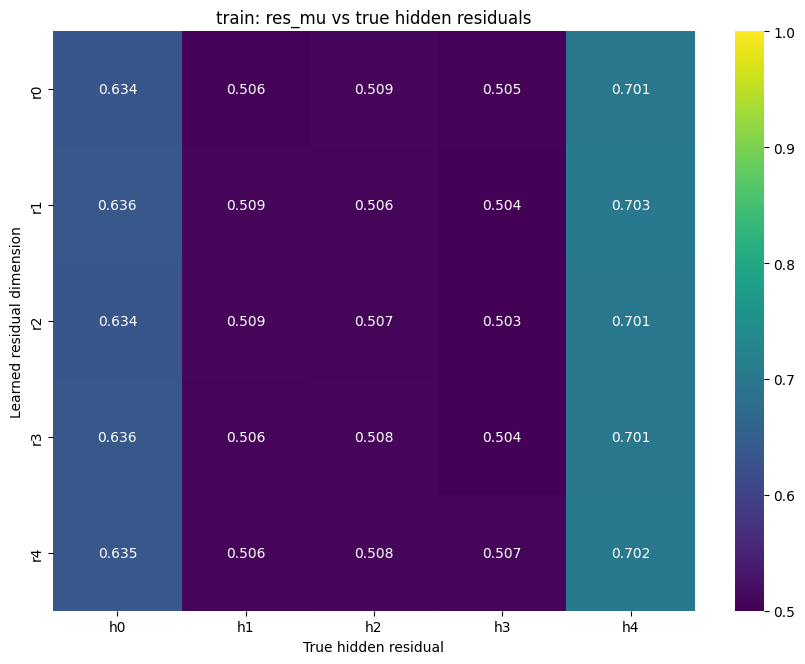

val best AUC per hidden residual: [0.6303 0.507  0.5145 0.52   0.6979]
val mean best AUC: 0.574
val mean best AUC, task-relevant only: 0.6641


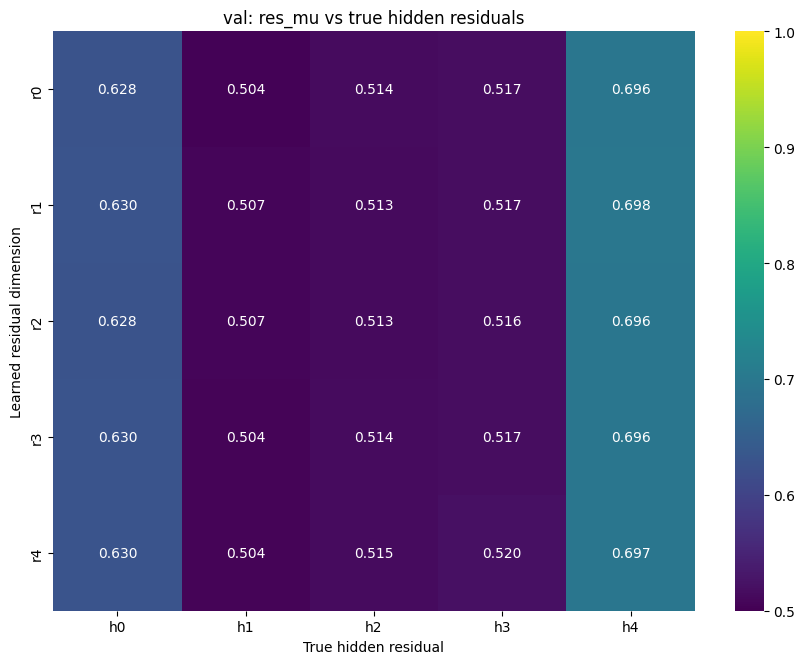

test best AUC per hidden residual: [0.6318 0.5062 0.5102 0.5068 0.7053]
test mean best AUC: 0.5721
test mean best AUC, task-relevant only: 0.6685


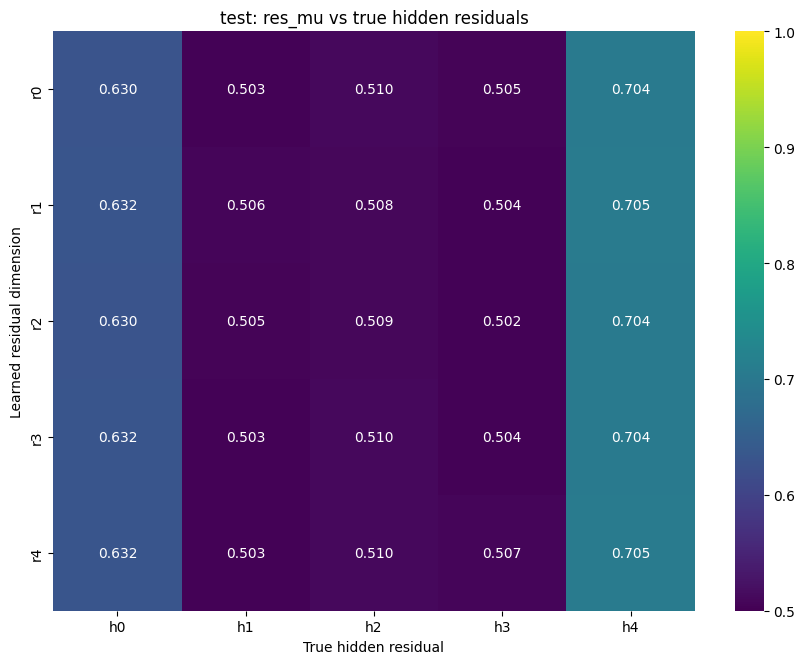

residual_probs
train best AUC per hidden residual: [0.6363 0.5091 0.5086 0.5068 0.7037]
train mean best AUC: 0.5729
train mean best AUC, task-relevant only: 0.67


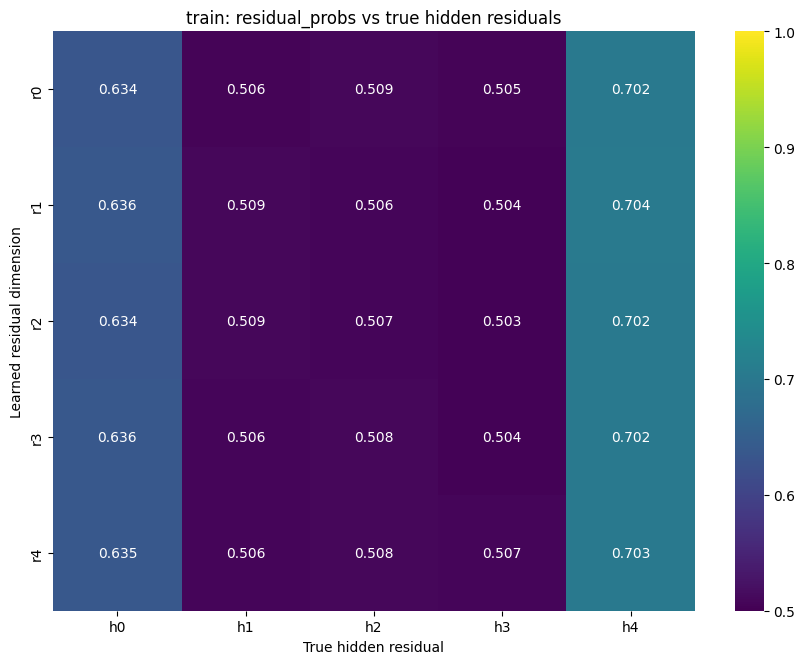

val best AUC per hidden residual: [0.6303 0.5069 0.5146 0.5201 0.6986]
val mean best AUC: 0.5741
val mean best AUC, task-relevant only: 0.6645


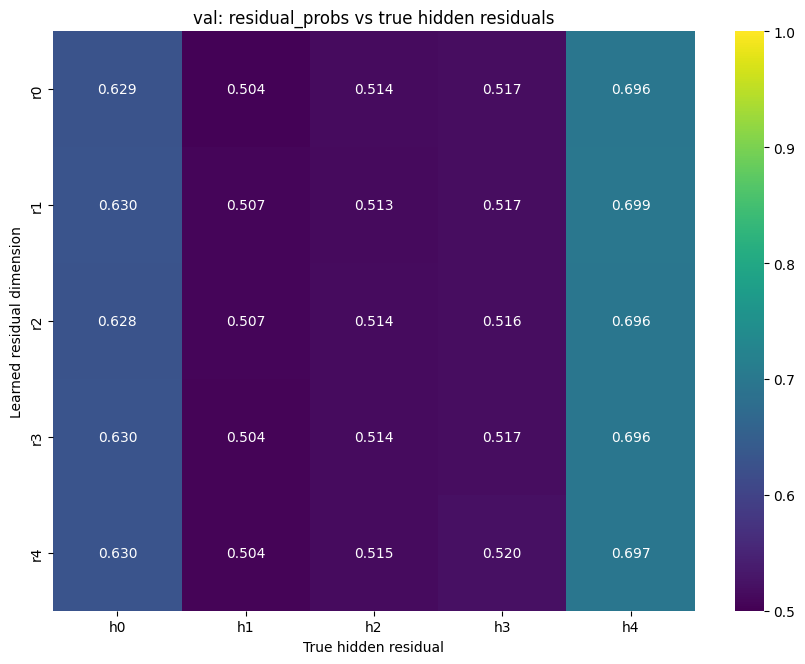

test best AUC per hidden residual: [0.632  0.5064 0.51   0.5067 0.7059]
test mean best AUC: 0.5722
test mean best AUC, task-relevant only: 0.6689


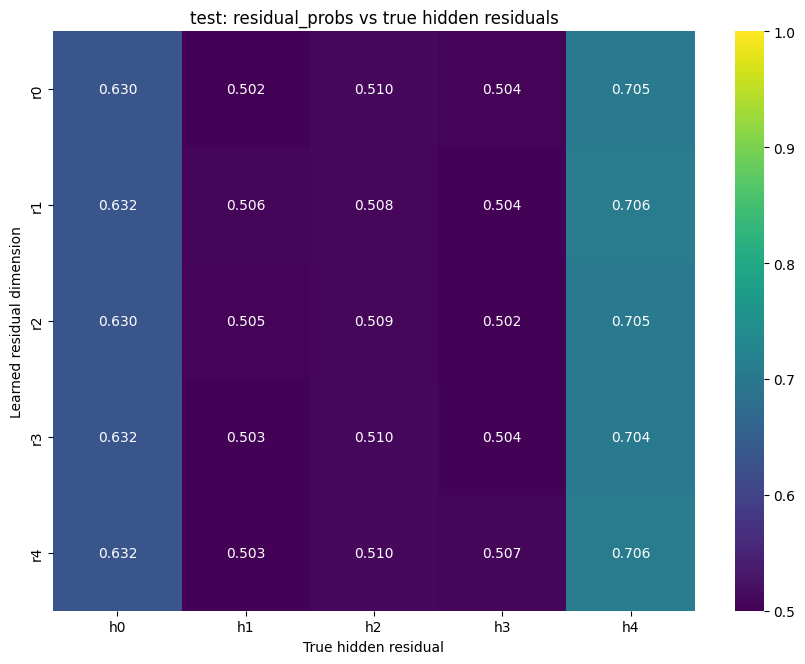

In [23]:
auc_tables = {}

for rep_name in ["res_mu", "residual_probs"]:
    print("=" * 80)
    print(rep_name)
    auc_tables[rep_name] = {}

    for split in ["train", "val", "test"]:
        auc, directions = residual_hidden_auc_matrix(splits[split][rep_name], splits[split]["hidden_residuals"])
        auc_tables[rep_name][split] = auc

        best = np.nanmax(auc, axis=0)
        print(f"{split} best AUC per hidden residual:", np.round(best, 4))
        print(f"{split} mean best AUC:", round(float(np.nanmean(best)), 4))
        if relevant_hidden:
            print(f"{split} mean best AUC, task-relevant only:", round(float(np.nanmean(best[relevant_hidden])), 4))

        plot_auc_matrix(auc, f"{split}: {rep_name} vs true hidden residuals")
        plt.show()


## Choose Matches On Validation, Evaluate On Test

This is the leakage-safe direct baseline. Validation chooses which learned residual dimension corresponds to each hidden residual. Test reports those fixed choices.


In [24]:
matches_train, auc_train, directions_train = match_hidden_to_residuals(
    splits["train"]["res_mu"],
    splits["train"]["hidden_residuals"],
)

matches_val, auc_val, directions_val = match_hidden_to_residuals(
    splits["val"]["res_mu"],
    splits["val"]["hidden_residuals"],
)

match_comparison = matches_val.merge(
    matches_train,
    on="hidden_idx",
    suffixes=("_val", "_train"),
)
match_comparison["same_residual_match"] = match_comparison["residual_idx_val"] == match_comparison["residual_idx_train"]
match_comparison = add_task_relevance(match_comparison.rename(columns={"hidden_idx": "hidden_idx"}), w_hid)
match_comparison


,hidden_idx,residual_idx_val,auc_val,direction_val,residual_idx_train,auc_train,direction_train,same_residual_match,w_hid,task_relevant
0,0,3,0.630335,positive,3,0.636189,positive,True,0.546616,True
1,1,1,0.507017,positive,1,0.509049,positive,True,0.000000,False
2,2,4,0.514518,negative,0,0.508710,positive,False,0.000000,False
3,3,4,0.520023,negative,4,0.506919,negative,True,0.000000,False
4,4,1,0.697891,positive,1,0.702760,positive,True,-0.837383,True


In [25]:
test_eval = evaluate_fixed_matches(
    splits["test"]["res_mu"],
    splits["test"]["hidden_residuals"],
    matches_val,
    threshold=0.0,
)
test_eval = add_task_relevance(test_eval, splits["test"]["w_hid"])

print("Test evaluation of validation-chosen residual-hidden matches")
display(test_eval)

summary = pd.Series({
    "mean_auc_all_hidden": test_eval["auc"].mean(),
    "mean_auc_task_relevant_hidden": test_eval.loc[test_eval["task_relevant"], "auc"].mean(),
    "num_hidden_auc_ge_0_7": int((test_eval["auc"] >= 0.7).sum()),
    "num_task_relevant_hidden_auc_ge_0_7": int(((test_eval["auc"] >= 0.7) & test_eval["task_relevant"]).sum()),
    "mean_accuracy_at_zero": test_eval["accuracy_at_threshold"].mean(),
})
summary


Test evaluation of validation-chosen residual-hidden matches


,hidden_idx,residual_idx,direction,auc,accuracy_at_threshold,f1_at_threshold,w_hid,task_relevant
0,0,3,positive,0.631770,0.5880,0.592402,0.546616,True
1,1,1,positive,0.506156,0.5006,0.490928,0.000000,False
2,2,4,negative,0.509978,0.5071,0.510769,0.000000,False
3,3,4,negative,0.506832,0.5083,0.511766,0.000000,False
4,4,1,positive,0.705086,0.6513,0.652793,-0.837383,True


mean_auc_all_hidden                    0.571964
mean_auc_task_relevant_hidden          0.668428
num_hidden_auc_ge_0_7                  1.000000
num_task_relevant_hidden_auc_ge_0_7    1.000000
mean_accuracy_at_zero                  0.551060
dtype: float64

## Direct Binary Interpretation

This treats each learned residual dimension as a binary discovered concept. This section is diagnostic: it reports the best test-set axis for each hidden residual, so do not use it to choose final matches. The leakage-safe report is the validation-chosen table above.


In [26]:
def binary_direct_recovery(residual_scores, hidden_residuals, score_type="mu"):
    R = to_numpy(residual_scores).astype(float)
    H = to_numpy(hidden_residuals).astype(int)
    threshold = 0.0 if score_type == "mu" else 0.5

    rows = []
    for h in range(H.shape[1]):
        for r in range(R.shape[1]):
            score = R[:, r]
            raw_auc = roc_auc_score(H[:, h], score)

            pred_pos = (score >= threshold).astype(int)
            pred_neg = (score < threshold).astype(int)
            acc_pos = accuracy_score(H[:, h], pred_pos)
            acc_neg = accuracy_score(H[:, h], pred_neg)

            if acc_pos >= acc_neg:
                best_acc = acc_pos
                best_f1 = f1_score(H[:, h], pred_pos)
                direction = "positive"
            else:
                best_acc = acc_neg
                best_f1 = f1_score(H[:, h], pred_neg)
                direction = "negative"

            rows.append({
                "hidden_idx": h,
                "residual_idx": r,
                "orientation_free_auc": max(raw_auc, 1 - raw_auc),
                "best_threshold_accuracy": best_acc,
                "best_threshold_f1": best_f1,
                "direction": direction,
            })

    return pd.DataFrame(rows)

for rep_name, score_type in [("res_mu", "mu"), ("residual_probs", "prob")]:
    print("=" * 80)
    print(rep_name)
    df_bin = binary_direct_recovery(splits["test"][rep_name], splits["test"]["hidden_residuals"], score_type=score_type)
    best = df_bin.sort_values("orientation_free_auc", ascending=False).groupby("hidden_idx").head(1).reset_index(drop=True)
    best = add_task_relevance(best, splits["test"]["w_hid"])
    display(best)


res_mu


,hidden_idx,residual_idx,orientation_free_auc,best_threshold_accuracy,best_threshold_f1,direction,w_hid,task_relevant
0,4,4,0.705293,0.6518,0.652217,positive,-0.837383,True
1,0,3,0.631770,0.5880,0.592402,positive,0.546616,True
2,2,0,0.510240,0.5074,0.512277,positive,0.000000,False
3,3,4,0.506832,0.5083,0.511766,negative,0.000000,False
4,1,1,0.506156,0.5006,0.490928,positive,0.000000,False


residual_probs


,hidden_idx,residual_idx,orientation_free_auc,best_threshold_accuracy,best_threshold_f1,direction,w_hid,task_relevant
0,4,1,0.705873,0.6514,0.652927,positive,-0.837383,True
1,0,1,0.631988,0.5886,0.592431,negative,0.546616,True
2,2,0,0.509968,0.5075,0.512714,positive,0.000000,False
3,3,4,0.506714,0.5077,0.511462,negative,0.000000,False
4,1,1,0.506354,0.5001,0.490470,positive,0.000000,False


## Distributed Probe Baseline

This asks whether hidden residual information is present in the residual vector even when it is not axis-aligned. The probe is trained on train residuals and evaluated on test residuals.


In [27]:
def distributed_probe_train_test(train_scores, train_hidden, test_scores, test_hidden):
    X_train = to_numpy(train_scores).astype(float)
    X_test = to_numpy(test_scores).astype(float)
    H_train = to_numpy(train_hidden).astype(int)
    H_test = to_numpy(test_hidden).astype(int)

    rows = []
    for h in range(H_train.shape[1]):
        if len(np.unique(H_train[:, h])) < 2 or len(np.unique(H_test[:, h])) < 2:
            continue

        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=5000, class_weight="balanced", random_state=0),
        )
        clf.fit(X_train, H_train[:, h])

        prob = clf.predict_proba(X_test)[:, 1]
        pred = (prob >= 0.5).astype(int)
        rows.append({
            "hidden_idx": h,
            "distributed_auc": roc_auc_score(H_test[:, h], prob),
            "distributed_accuracy": accuracy_score(H_test[:, h], pred),
            "distributed_f1": f1_score(H_test[:, h], pred),
        })

    return pd.DataFrame(rows)

probe_eval = distributed_probe_train_test(
    splits["train"]["res_mu"],
    splits["train"]["hidden_residuals"],
    splits["test"]["res_mu"],
    splits["test"]["hidden_residuals"],
)
probe_eval = add_task_relevance(probe_eval, splits["test"]["w_hid"])
probe_eval


,hidden_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,task_relevant
0,0,0.640631,0.5964,0.605088,0.546616,True
1,1,0.575572,0.5602,0.556474,0.000000,False
2,2,0.543807,0.5338,0.539419,0.000000,False
3,3,0.583890,0.5610,0.562400,0.000000,False
4,4,0.706317,0.6504,0.646726,-0.837383,True


## Interpretation Guide

- Strong validation-chosen test AUCs mean the residual channel itself contains axis-aligned discovered hidden concepts.
- If distributed probe AUC is much higher than axis-aligned AUC, hidden information is present but entangled across residual dimensions.
- If only task-relevant hidden residuals are recovered, that is expected: the residual channel is trained to preserve task-relevant missing information, not necessarily every hidden factor.
- The next step after this baseline is SAE discovery on `train/res_mu.pt`, with feature activations evaluated on val/test.
